# XAI-Compress — Analyse scientifique reproductible

Ce notebook analyse exclusivement les sources, checkpoints, métriques et résultats présents dans le dépôt. Il ne lance pas un nouvel entraînement et ne fabrique aucune valeur. Le benchmark principal est `hybrid-v3-final-140-v1`, marqué `ACCEPTED` par son artefact source. Une acceptation interne n'est pas une certification externe.


## 1. Objectif et principes

La compression **sans perte** transforme une séquence d'octets $X$ en un conteneur $C(X)$ qui doit être exactement inversible :

$$D(C(X)) = X$$

XAI-Compress combine des codecs classiques, une prédiction neuronale causale, des stratégies Hybrid V1/V2/V3, et Selector V2. Le sélecteur ne remplace pas les codecs : il classe des stratégies candidates. Hybrid V3 Top-3 mesure ensuite jusqu'à trois candidats afin de choisir un compromis opérationnel. Le résultat est encapsulé dans un conteneur XAIC avec contrôle d'intégrité.

Les métriques fondamentales sont :

$$CR=\frac{S_{original}}{S_{compressed}},\qquad Saving(\%)=\left(1-\frac{S_{compressed}}{S_{original}}\right)100$$

$$BPB=8\frac{S_{compressed}}{S_{original}},\qquad SHA256(X)=SHA256(D(C(X)))$$

Pour une source discrète, $H(X)=-\sum_x p(x)\log_2p(x)$. Un modèle causal estime $P(x_t\mid x_1,\ldots,x_{t-1})$ et minimise

$$\mathcal L=-\frac1N\sum_t\log p_\theta(x_t\mid context),\qquad \ell(x)\approx-\log_2p(x).$$

Une meilleure probabilité prédictive peut réduire la longueur de code idéale, mais le coût du modèle, les métadonnées, la quantification et le codeur entropique déterminent le résultat XAIC réel.


In [1]:
from pathlib import Path
import json, hashlib, math, statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'engines' / 'XAI-Compress').is_dir():
    ROOT = ROOT.parent
ENGINE = ROOT / 'engines' / 'XAI-Compress'
V3 = ENGINE / 'results' / 'hybrid_v3'
summary = json.loads((V3 / 'benchmark_summary.json').read_text(encoding='utf-8'))
bench = pd.read_csv(V3 / 'benchmark.csv')
manifest = pd.read_csv(V3 / 'benchmark_manifest.csv')
selector = json.loads((ENGINE / 'checkpoints' / 'selector_v2' / 'metrics.json').read_text(encoding='utf-8'))
assert summary['status'] == 'ACCEPTED' and summary['common_source_count'] == 140
assert bench['roundtrip_sha_pass'].astype(str).str.lower().eq('true').all()
print(summary['benchmark_version'], len(manifest), manifest['original_bytes'].sum())


hybrid-v3-final-140-v1 140 368446658


## 2. CausalByteGRU : architecture réellement implémentée

`xai_compress/model.py` définit un vocabulaire de 257 symboles (256 octets + BOS), une couche `nn.Embedding`, un `nn.GRU` causal et une projection linéaire vers 256 logits. Les dimensions appartiennent au `ModelConfig` du checkpoint et ne sont donc pas supposées constantes.

Pour l'entrée embarquée $e_t=E[x_t]$, une notation GRU standard est :

$$z_t=\sigma(W_ze_t+U_zh_{t-1}+b_z),\qquad r_t=\sigma(W_re_t+U_rh_{t-1}+b_r)$$

$$\widetilde h_t=\tanh(W_he_t+U_h(r_t\odot h_{t-1})+b_h)$$

$$h_t=(1-z_t)\odot h_{t-1}+z_t\odot\widetilde h_t$$

La convention interne de PyTorch peut ordonner les portes différemment, mais ces équations décrivent le mécanisme. La projection donne $o_t=W_oh_t+b_o$ et

$$p_\theta(x_t=k\mid x_{<t})=\operatorname{softmax}(o_t)_k.$$

Le réseau ne reconstruit pas approximativement les octets : ses probabilités alimentent le codeur entropique, qui doit rester exactement réversible.


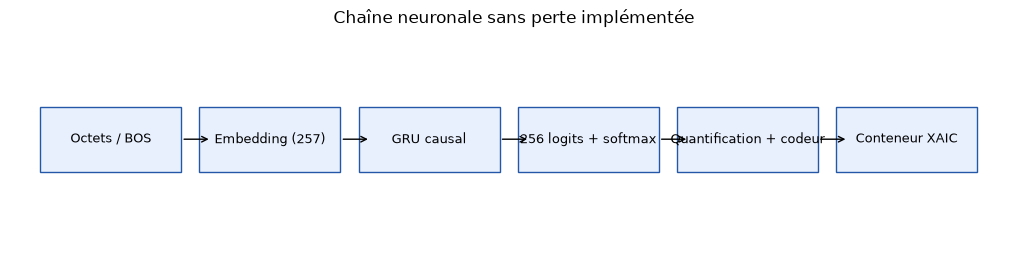

In [2]:
fig, ax = plt.subplots(figsize=(13, 2.8)); ax.axis('off')
labels=['Octets / BOS','Embedding (257)','GRU causal','256 logits + softmax','Quantification + codeur','Conteneur XAIC']
xs=np.linspace(.03,.82,len(labels))
for x,label in zip(xs,labels): ax.add_patch(plt.Rectangle((x,.35),.14,.3,fc='#e8f0fe',ec='#2457a7')); ax.text(x+.07,.5,label,ha='center',va='center',fontsize=9)
for x in xs[:-1]: ax.annotate('',(x+.17,.5),(x+.14,.5),arrowprops={'arrowstyle':'->'})
ax.set_title('Chaîne neuronale sans perte implémentée'); plt.show()


## 3. Données et biais d'échantillonnage

Le manifeste Hybrid V3 décrit 140 fichiers tenus à l'écart pour le benchmark final. Le corpus Selector V2 contient des groupes train/validation/test, des fichiers réels et synthétiques. Les chemins montrent aussi des caches de build et sorties de test : ils sont bien des fichiers mesurés, mais rendent le corpus dépendant de l'état du dépôt et limitent la généralisation. Les extensions, tailles et catégories ne représentent pas nécessairement les usages réels d'une population externe.


   files       bytes  train  validation  test
0   1046  2360235968    735         156   155


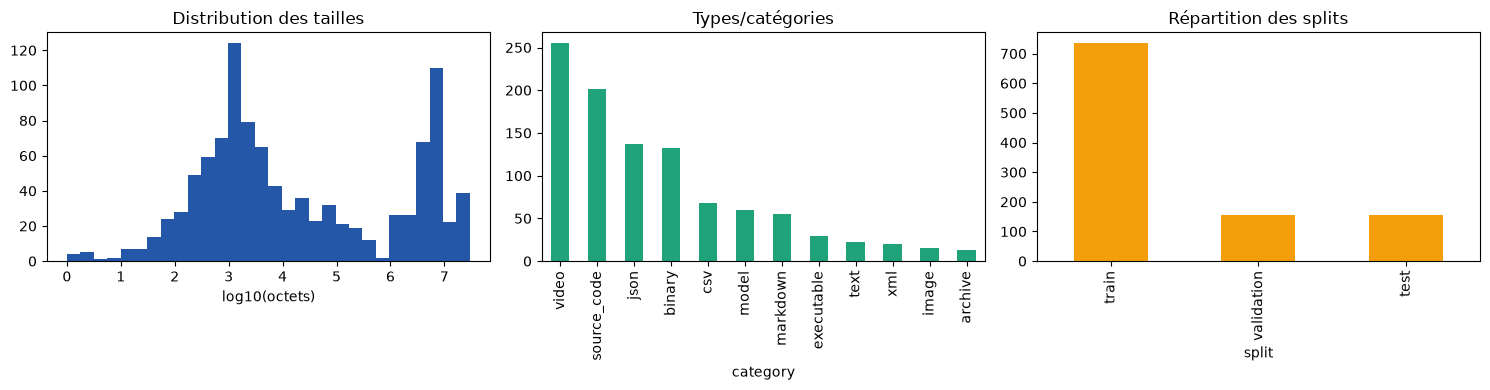

In [3]:
corpus = pd.read_csv(ENGINE/'data'/'hybrid_selector'/'corpus_manifest.csv')
print(pd.DataFrame({'files':[len(corpus)],'bytes':[corpus.original_bytes.sum()],'train':[sum(corpus.split=='train')],'validation':[sum(corpus.split=='validation')],'test':[sum(corpus.split=='test')]}))
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].hist(np.log10(corpus.original_bytes.clip(lower=1)),bins=30,color='#2457a7');axes[0].set_title('Distribution des tailles');axes[0].set_xlabel('log10(octets)')
corpus.category.value_counts().head(12).plot.bar(ax=axes[1],color='#20a37a',title='Types/catégories')
corpus.split.value_counts().plot.bar(ax=axes[2],color='#f59e0b',title='Répartition des splits')
plt.tight_layout();plt.show()


## 4. Entraînement et comparaison des checkpoints

Les résumés et CSV disponibles sont découverts automatiquement. Une perte/BPB absente reste absente : **« Non disponible dans les artefacts expérimentaux du dépôt. »** Les BPB de validation de corpus différents ne constituent pas une comparaison universelle de compression.


In [4]:
rows=[]
for summary_path in sorted((ENGINE/'checkpoints').rglob('*.summary.json')):
    data=json.loads(summary_path.read_text(encoding='utf-8'))
    checkpoint=ENGINE/data.get('checkpoint','') if data.get('checkpoint') and not Path(data['checkpoint']).is_absolute() else summary_path.with_suffix('').with_suffix('.pt')
    cfg=data.get('model_config',{})
    rows.append({'MODEL':cfg.get('architecture_id','Non disponible'),'CHECKPOINT':str(summary_path.relative_to(ENGINE)),'PARAMETERS':data.get('parameter_count'),'CONTEXT':cfg.get('context_length') or data.get('train_dataset',{}).get('context_length'),'VALIDATION LOSS':data.get('best_validation_cross_entropy'),'VALIDATION BPB':data.get('best_validation_bpb'),'SIZE':checkpoint.stat().st_size if checkpoint.exists() else None,'STATUS':'measured summary'})
checkpoints=pd.DataFrame(rows)
display(checkpoints)


,MODEL,CHECKPOINT,PARAMETERS,CONTEXT,VALIDATION LOSS,VALIDATION BPB,SIZE,STATUS
0,causal-byte-gru-v1,checkpoints\gru_v2_hq.summary.json,789888.0,256,5.533842,7.983647,9492803.0,measured summary
1,causal-byte-gru-v1,checkpoints\kaggle\best.summary.json,1700800.0,256,5.523488,7.968708,NaN,measured summary
2,conv-image-autoencoder-v1,checkpoints\neural_lossy_v1\validation.summary...,NaN,1,NaN,NaN,136080.0,measured summary
3,causal-byte-gru-v1,checkpoints\phase_i_v1_128_domain.summary.json,123968.0,128,0.595072,0.858508,1497771.0,measured summary
4,causal-byte-gru-v1,checkpoints\phase_i_v1_128_sanity.summary.json,123968.0,128,5.540076,7.992641,1497771.0,measured summary
5,causal-byte-gru-v1,checkpoints\phase_j_v1_128.summary.json,123968.0,128,0.561145,0.809561,1497533.0,measured summary
6,causal-byte-gru-v1,checkpoints\phase_j_v1_256.summary.json,123968.0,128,0.601710,0.868084,1497533.0,measured summary


C:\Users\ss\AppData\Local\Temp\ipykernel_3528\586316613.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame=pd.read_csv(p);frame['checkpoint_metrics']=str(p.relative_to(ENGINE));metric_frames.append(frame)


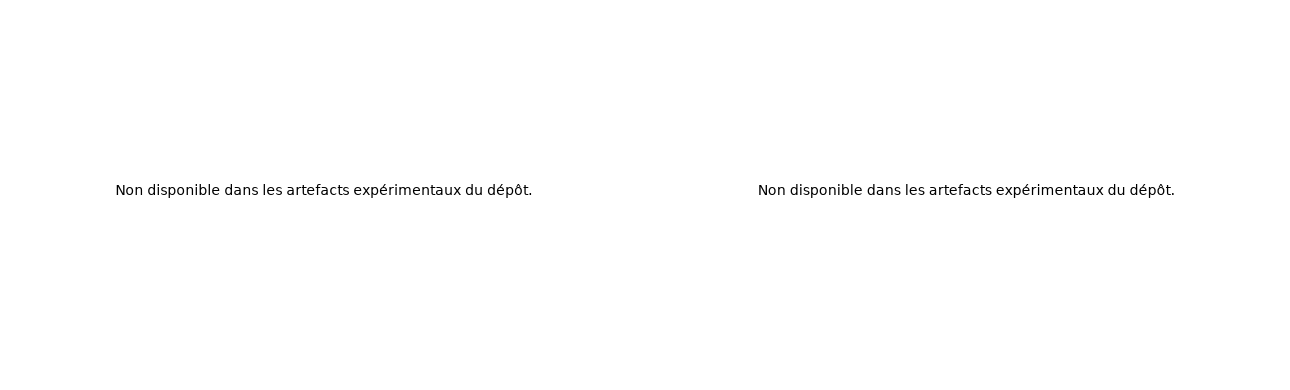

In [6]:
metric_frames=[]
for p in sorted((ENGINE/'checkpoints').rglob('*.metrics.csv')):
    try:
        frame=pd.read_csv(p);frame['checkpoint_metrics']=str(p.relative_to(ENGINE));metric_frames.append(frame)
    except Exception as exc: print('Unreadable',p,exc)
if metric_frames:
    metrics=pd.concat(metric_frames,ignore_index=True,sort=False)
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    x='epoch' if 'epoch' in metrics else metrics.index
    for col,ax in [('train_loss',axes[0]),('validation_bpb',axes[1])]:
        if col in metrics:
            for name,g in metrics.dropna(subset=[col]).groupby('checkpoint_metrics'):ax.plot(g['epoch'] if 'epoch' in g else g.index,g[col],label=name.split('/')[-1])
            ax.set_title(col);ax.legend(fontsize=7)
        else:ax.text(.5,.5,'Non disponible dans les artefacts expérimentaux du dépôt.',ha='center',wrap=True);ax.axis('off')
    plt.tight_layout();plt.show()


## 5. Selector V2

Les métriques enregistrées sont Top-1 = exactitude de la première stratégie, Top-2/Top-3 = rappel contenant l'optimum mesuré. **L'exactitude de classification du Selector n'est pas la qualité de compression finale** : Hybrid V3 mesure les candidats routés et les métadonnées/coûts du conteneur comptent encore.


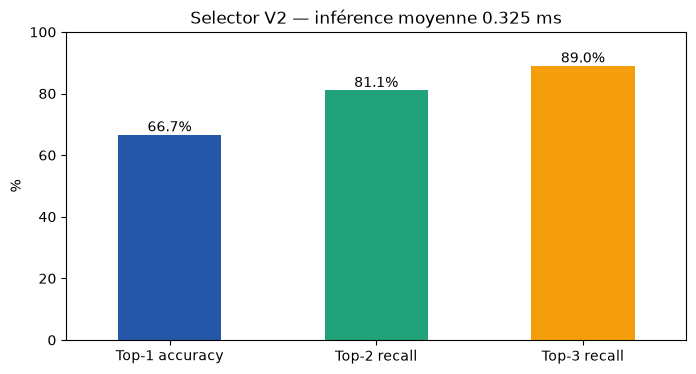

Matrice de confusion: Non disponible dans les artefacts expérimentaux du dépôt.


In [7]:
sel=pd.Series({'Top-1 accuracy':selector['top_1_accuracy'],'Top-2 recall':selector['top_2_recall'],'Top-3 recall':selector['top_3_recall']})
ax=(100*sel).plot.bar(figsize=(8,4),color=['#2457a7','#20a37a','#f59e0b'],ylim=(0,100),ylabel='%');ax.bar_label(ax.containers[0],fmt='%.1f%%');ax.set_title(f"Selector V2 — inférence moyenne {selector['mean_inference_ms']:.3f} ms");plt.xticks(rotation=0);plt.show()
print('Matrice de confusion: Non disponible dans les artefacts expérimentaux du dépôt.')


## 6. Benchmark tenu à l'écart : Hybrid V1/V2/V3 Top-3/Brotli-11

Les quatre méthodes ci-dessous partagent 140 identifiants source et 368 446 658 octets originaux. Les artefacts déclarent une frontière de temps de bout en bout et une égalité SHA-256. La politique de répétition est asymétrique : trois répétitions pour les hybrides jusqu'à 4 MiB, une au-delà, mais une seule pour Brotli-11. Les intervalles de temps ne doivent donc pas être interprétés comme une expérience parfaitement répétée.


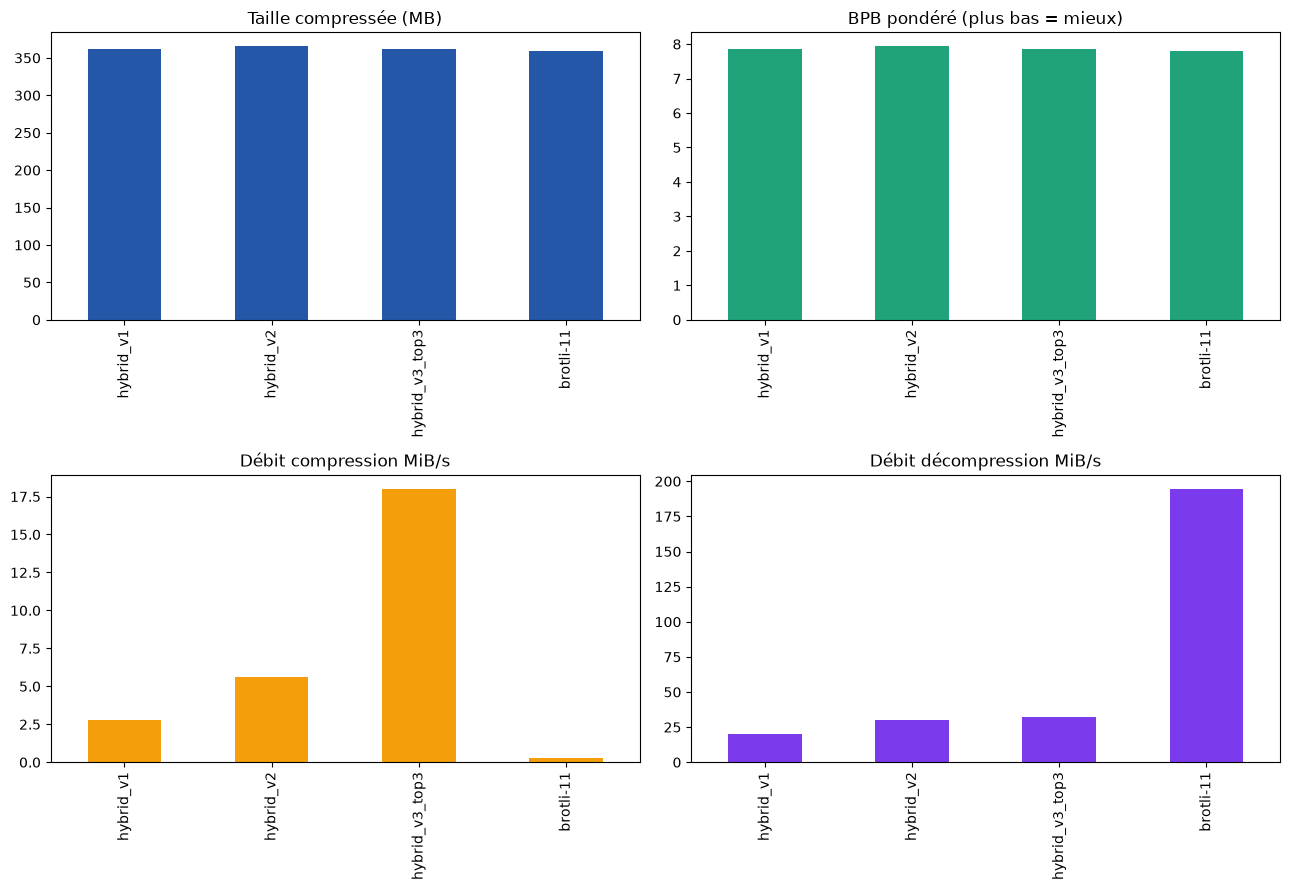

,compressed_bytes,weighted_bpb,compression_MiB_s,decompression_MiB_s,sha_pass
hybrid_v1,361712014,7.853772,2.816161,20.174976,True
hybrid_v2,365898448,7.944671,5.629025,30.124013,True
hybrid_v3_top3,362188760,7.864124,18.027349,32.20272,True
brotli-11,359459933,7.804873,0.251334,194.827433,True


In [8]:
methods=['hybrid_v1','hybrid_v2','hybrid_v3_top3','brotli-11']
agg=pd.DataFrame({m:summary['methods'][m] for m in methods}).T
fig,axes=plt.subplots(2,2,figsize=(13,9))
agg.compressed_bytes.div(1e6).plot.bar(ax=axes[0,0],title='Taille compressée (MB)',color='#2457a7')
agg.weighted_bpb.plot.bar(ax=axes[0,1],title='BPB pondéré (plus bas = mieux)',color='#20a37a')
agg.compression_MiB_s.plot.bar(ax=axes[1,0],title='Débit compression MiB/s',color='#f59e0b')
agg.decompression_MiB_s.plot.bar(ax=axes[1,1],title='Débit décompression MiB/s',color='#7c3aed')
plt.tight_layout();plt.show();display(agg[['compressed_bytes','weighted_bpb','compression_MiB_s','decompression_MiB_s','sha_pass']])


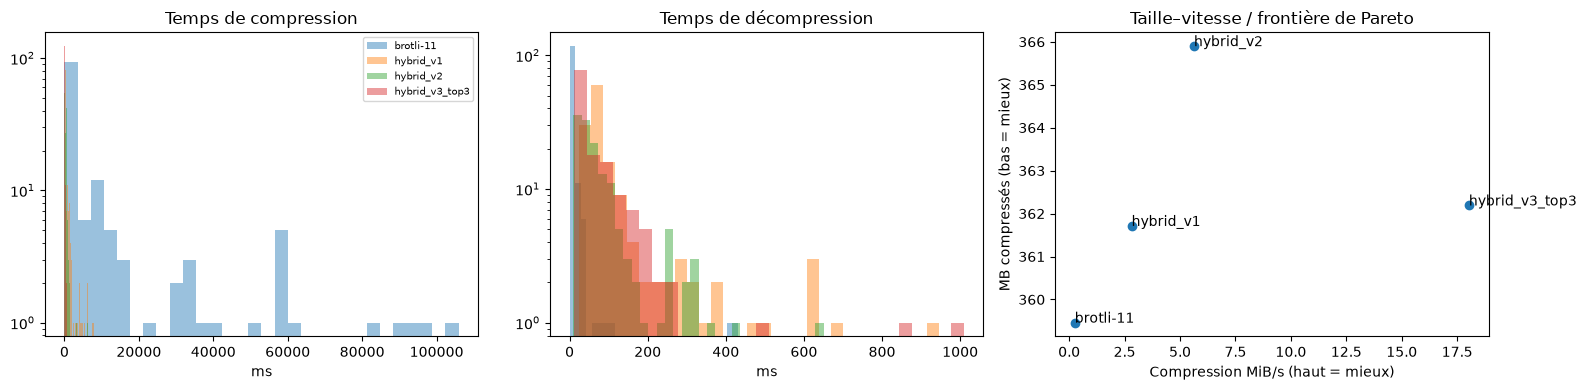

In [9]:
base=bench[bench.method.isin(methods)].copy()
fig,axes=plt.subplots(1,3,figsize=(16,4))
for m,g in base.groupby('method'):axes[0].hist(g.compression_ms,bins=30,alpha=.45,label=m);axes[1].hist(g.decompression_ms,bins=30,alpha=.45,label=m)
axes[0].set_title('Temps de compression');axes[0].set_xlabel('ms');axes[0].set_yscale('log');axes[1].set_title('Temps de décompression');axes[1].set_xlabel('ms');axes[1].set_yscale('log')
axes[2].scatter(agg.compression_MiB_s,agg.compressed_bytes/1e6)
for m in methods:axes[2].annotate(m,(agg.loc[m,'compression_MiB_s'],agg.loc[m,'compressed_bytes']/1e6))
axes[2].set(xlabel='Compression MiB/s (haut = mieux)',ylabel='MB compressés (bas = mieux)',title='Taille–vitesse / frontière de Pareto')
axes[0].legend(fontsize=7);plt.tight_layout();plt.show()


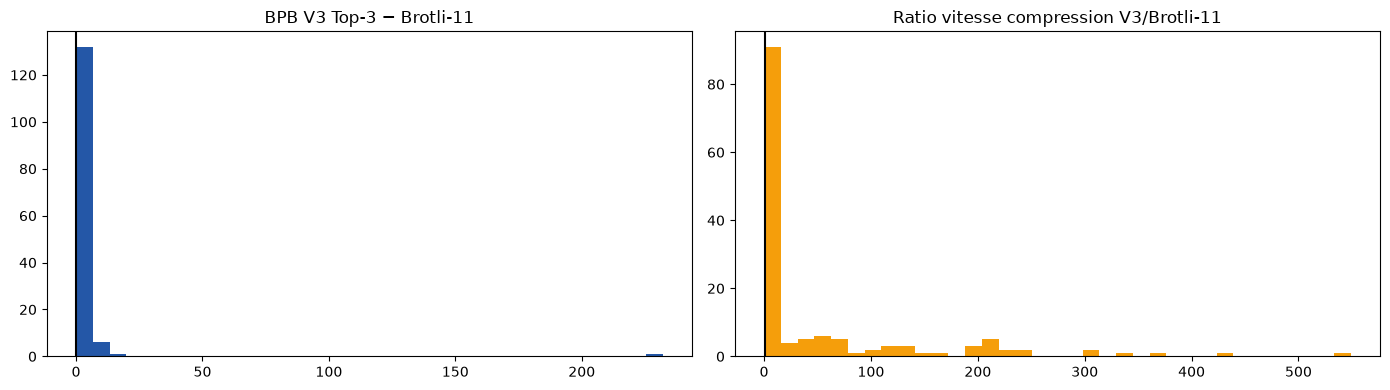

In [10]:
pivot=base.pivot(index='source_id',columns='method',values=['actual_bpb','compression_MiB_s','original_bytes','category','size_bucket'])
diff=pivot['actual_bpb']['hybrid_v3_top3'].astype(float)-pivot['actual_bpb']['brotli-11'].astype(float)
speed=pivot['compression_MiB_s']['hybrid_v3_top3'].astype(float)/pivot['compression_MiB_s']['brotli-11'].astype(float)
fig,axes=plt.subplots(1,2,figsize=(14,4));axes[0].hist(diff,bins=35,color='#2457a7');axes[0].axvline(0,color='black');axes[0].set_title('BPB V3 Top-3 − Brotli-11');axes[1].hist(speed.replace([np.inf],np.nan).dropna(),bins=35,color='#f59e0b');axes[1].axvline(1,color='black');axes[1].set_title('Ratio vitesse compression V3/Brotli-11');plt.tight_layout();plt.show()


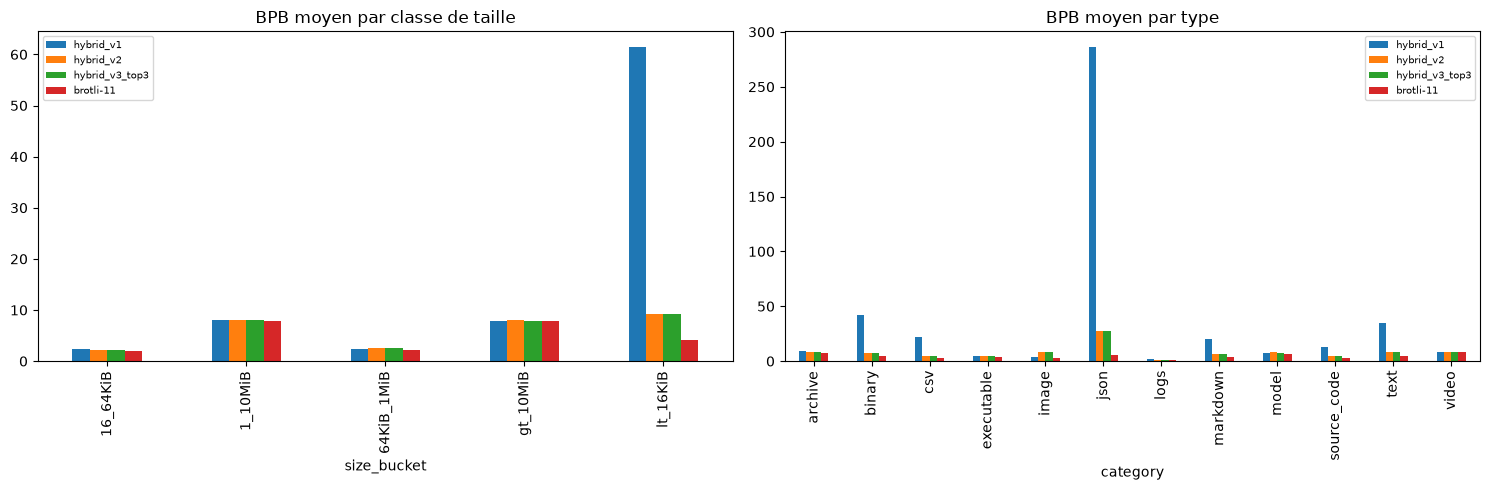

In [11]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
base.groupby(['size_bucket','method']).actual_bpb.mean().unstack().reindex(columns=methods).plot.bar(ax=axes[0],title='BPB moyen par classe de taille')
base.groupby(['category','method']).actual_bpb.mean().unstack().reindex(columns=methods).plot.bar(ax=axes[1],title='BPB moyen par type')
axes[0].legend(fontsize=7);axes[1].legend(fontsize=7);plt.tight_layout();plt.show()


## 7. Statistiques et exactitude

Les statistiques descriptives sont calculées par fichier. Un intervalle bootstrap apparié à 95 % est calculé uniquement pour la différence BPB V3−Brotli sur les 140 paires. Il quantifie l'incertitude d'échantillonnage de ce corpus, pas la variabilité machine, car Brotli-11 n'a qu'une répétition.


In [12]:
stats=base.groupby('method').agg(bpb_mean=('actual_bpb','mean'),bpb_median=('actual_bpb','median'),bpb_std=('actual_bpb','std'),bpb_p05=('actual_bpb',lambda x:x.quantile(.05)),bpb_p95=('actual_bpb',lambda x:x.quantile(.95)),compress_median=('compression_MiB_s','median'),decompress_median=('decompression_MiB_s','median'))
rng=np.random.default_rng(20260920);values=diff.to_numpy();boot=np.array([rng.choice(values,len(values),replace=True).mean() for _ in range(10000)])
print('Différence BPB moyenne V3−Brotli:',values.mean(),'IC bootstrap 95%:',np.quantile(boot,[.025,.975]));display(stats)


Différence BPB moyenne V3−Brotli: 3.0072629805227042 IC bootstrap 95%: [1.08075104 6.5504001 ]


,bpb_mean,bpb_median,bpb_std,bpb_p05,bpb_p95,compress_median,decompress_median
method,,,,,,,
brotli-11,5.122849,3.808398,3.075931,1.178203,8.000646,0.225465,51.805998
hybrid_v1,37.947413,8.004153,260.293108,1.536119,75.107041,0.036567,0.074237
hybrid_v2,8.159856,6.180729,21.444134,1.611174,13.534351,0.012655,0.134557
hybrid_v3_top3,8.130112,6.180729,21.444315,1.535887,13.638072,0.178600,0.183977


In [13]:
correctness=base[['source_id','method','source_sha256','compressed_bytes','roundtrip_sha_pass']].copy();correctness['decompressed_sha256']='verified equal to source_sha256 in benchmark artifact';correctness['match']=correctness.roundtrip_sha_pass.astype(bool)
display(correctness.head(10));print('round_trip_success_rate =',correctness['match'].mean())
assert correctness['match'].all()


,source_id,method,source_sha256,compressed_bytes,roundtrip_sha_pass,decompressed_sha256,match
0,86aebd2a6ca744d6ce03,hybrid_v1,d3ded09d755c7c896e54b00b6b49be489d6d7daaf86440...,3368,True,verified equal to source_sha256 in benchmark a...,True
1,ab9fd50e606430ff1ad4,hybrid_v1,1097a9c63933d92fb6d40acbb5871c0881f69ed68b4605...,10874623,True,verified equal to source_sha256 in benchmark a...,True
2,c00053085b900f5df548,hybrid_v1,fd5f5bcaba1cf150622596027fefdd22ac7a61db2dde47...,11804339,True,verified equal to source_sha256 in benchmark a...,True
3,5f8724e09072ab9a265f,hybrid_v1,58a43472c935cb48bcf1270662961f78f69d6accf404d4...,818,True,verified equal to source_sha256 in benchmark a...,True
4,a79486349dd2e056bef1,hybrid_v1,002ae1a4bd438cf5ffb03a9d964990dfeb9389bcfb323b...,824,True,verified equal to source_sha256 in benchmark a...,True
5,40edde3ff58386c6e648,hybrid_v1,5b3ee2ef314de0dc6adc83b4a21f02ddd964bc5700e813...,872,True,verified equal to source_sha256 in benchmark a...,True
6,f6d8ac25d8ced35c97bb,hybrid_v1,2d49913b6961e7886aceaa2bf12fd148a463f5077b9d48...,933,True,verified equal to source_sha256 in benchmark a...,True
7,cc0a768c16bc4f521d5e,hybrid_v1,d6b16579d5f6a6066cc22323c4e34adb82020f7b75378b...,1118,True,verified equal to source_sha256 in benchmark a...,True
8,5cfd18ecb4615302b290,hybrid_v1,162dd67b8042a9e57c67e0cc11aa979e3b2d7b44e350a9...,1934,True,verified equal to source_sha256 in benchmark a...,True
9,1364093c2cd97d6b467d,hybrid_v1,ad9c84765af109b753aa1444e9515e89579b53967bd1ba...,2169,True,verified equal to source_sha256 in benchmark a...,True


round_trip_success_rate = 1.0


## 8. Décision Hybrid V3 et sécurité

Le chemin réel est :

**Fichier → extraction de caractéristiques → Selector V2 → Top-k candidats → évaluation des candidats → route sélectionnée → conteneur XAIC.**

Top-3 augmente le rappel enregistré de l'optimum à 89,03 %, au prix de mesures candidates supplémentaires. C'est un compromis, pas une preuve que trois est universellement optimal.

Le pipeline de sécurité applicatif est extérieur à la métrique de compression :

**Upload → SHA-256 → ClamAV → YARA → compression → décompression de contrôle → SHA-256 → scan de sortie.**

Le backend échoue en mode fermé : si ClamAV/YARA est indisponible ou si l'intégrité échoue, les octets ne sont pas publiés. Aucun échantillon malveillant n'est nécessaire dans cette analyse.


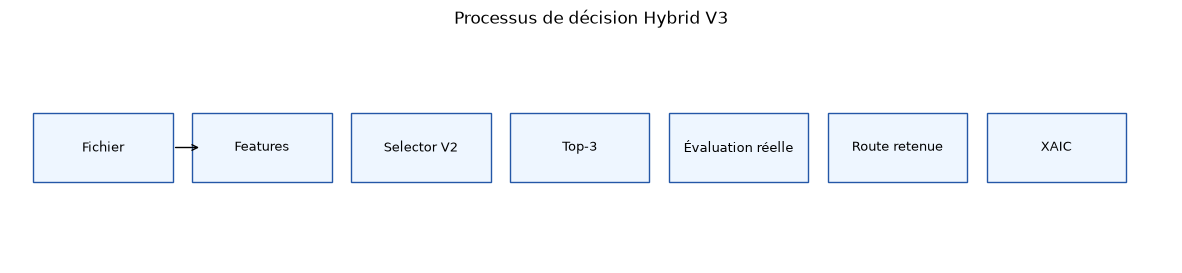

In [14]:
fig,ax=plt.subplots(figsize=(15,3));ax.axis('off');labels=['Fichier','Features','Selector V2','Top-3','Évaluation réelle','Route retenue','XAIC'];xs=np.linspace(.02,.84,len(labels))
for x,label in zip(xs,labels):ax.add_patch(plt.Rectangle((x,.35),.12,.3,fc='#eef6ff',ec='#2457a7'));ax.text(x+.06,.5,label,ha='center',va='center',fontsize=9)
for x in xs[:-1]:ax.annotate('',(x+.145,.5),(x+.12,.5),arrowprops={'arrowstyle':'->'});ax.set_title('Processus de décision Hybrid V3');plt.show()


## 9. Limites et conclusion équilibrée

Limites : corpus de taille finie et dépendant de l'état du dépôt; présence de caches/builds; matériel et charge machine; politique de répétition asymétrique; coût et taille des checkpoints; inférence séquentielle; erreurs du Selector; dépendance au domaine; généralisation non démontrée; métriques d'entraînement hétérogènes; absence de matrice de confusion brute; différence entre preuve locale et disponibilité de production.

Sur ce benchmark, **Brotli-11 produit la meilleure taille** (359 459 933 octets, 7,8049 BPB) et la meilleure décompression agrégée. **Hybrid V3 Top-3 compresse beaucoup plus vite** selon les débits enregistrés (18,03 contre 0,251 MiB/s) mais produit 2 728 827 octets de plus. Hybrid V3 améliore fortement le débit par rapport à V1/V2 tout en restant proche de V1 en taille. Ce résultat soutient un compromis opérationnel sur ce corpus; il ne soutient pas l'affirmation « l'IA est universellement meilleure ».

La conclusion doit donc distinguer ratio, vitesse d'encodage, vitesse de décodage, coût/taille du modèle et contraintes d'exploitation. Toute disponibilité scanner ou validation client en production exige des preuves séparées.


In [15]:
brotli=agg.loc['brotli-11'];v3=agg.loc['hybrid_v3_top3']
print({'best_size':'brotli-11','v3_extra_bytes':int(v3.compressed_bytes-brotli.compressed_bytes),'v3_vs_brotli_compression_speed_ratio':float(v3.compression_MiB_s/brotli.compression_MiB_s),'best_decode':'brotli-11','all_sha_pass':bool(agg.sha_pass.all())})


{'best_size': 'brotli-11', 'v3_extra_bytes': 2728827, 'v3_vs_brotli_compression_speed_ratio': 71.72668457297502, 'best_decode': 'brotli-11', 'all_sha_pass': True}
